# 1. Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
# from pprint import pprint
from datetime import timedelta, datetime
import gnss_lib_py as glp
# from gnss_lib_py.utils.ephemeris_downloader import load_ephemeris
from astropy.time import Time # datetime to TAI
import plotly.graph_objects as go

# from dataclasses import dataclass
# from pymap3d import eci2ecef
# from src.conversions import eci_to_ecef
from astropy.coordinates import get_body, ITRS
from lunarsky import MCMF
from astropy import units as u

from src.lugre_parser import get_unique_timestamps, lugre_parser, get_unique_times, gps_seconds_to_gps_weeks



In [214]:
import pylupnt as pnt

Downloaded data to LuPNT_data


In [215]:
plt.rcdefaults()

## 1.1 Importing Data

In [216]:
data_path = Path().joinpath("LuGRE Mission Data/L0/TLM/")
set_ids = get_unique_timestamps(data_path) # get all unique timestamps in the directory

# shrink set_ids to the ones on lunar surface
surface_ids = [set_id for set_id in set_ids if "_S_" in set_id]
print(len(surface_ids), "surface data sets found")


datasets = [lugre_parser(data_path, set_id) for set_id in surface_ids]

7 surface data sets found


/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Use

In [217]:
print([datasets[0][i].columns for i in datasets[0].keys()])

[Index(['date', 'time', 'duration', 'phase', 'opnumber', 'index'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'signalId', 'svid', 'doppler',
       'codePhase', 'acfCorr', 'noiseFloor', 'acqMode', 'CN0'],
      dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'appName', 'wn', 'tow', 'decimals',
       'nSat', 'posX', 'posY', 'posZ', 'velX', 'velY', 'velZ', 'posStd',
       'velStd', 'timStd', 'clockBias', 'clockDrift', 'ggto', 'GDOP', 'PDOP',
       'HDOP', 'VDOP', 'TDOP'],
      dtype='object'), Index(['rxTime', 'signal', 'svId', 'Toe', 'Toc', 'iodNav', 'iodE', 'iodC'], dtype='object'), Index(['Receiver Time [s]', 'Clock Bias [m]', 'ClockDrift [m/s]'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'measures', 'svid', 'prRaw', 'cn0',
       'signalId', 'fdRaw', 'accDoppler', 'fdRateRaw'],
      dtype='object')]


In [218]:
dataset_id = 5
lugre_df = datasets[dataset_id]
nav = lugre_df["nav"]

rx_ecef_km = nav[["posX", "posY", "posZ"]].to_numpy() / 1000.0

## 1.2 Time Transforms

In [219]:
gps_time_s = nav["rxTime"].to_numpy()
utc_times = [ glp.gps_millis_to_datetime(t*1000) for t in gps_time_s ]

# Time for Astropy
t_ast = Time(utc_times, scale='utc')

# GCRS to ITRS (ECEF)
moon_gcrs = get_body("moon", t_ast)
moon_itrs = moon_gcrs.transform_to(ITRS(obstime=t_ast))

# Extract as km for plotting
moon_ecef_km = np.column_stack([
    moon_itrs.x.to(u.km).value,
    moon_itrs.y.to(u.km).value,
    moon_itrs.z.to(u.km).value
])


# 2. Initial Plots

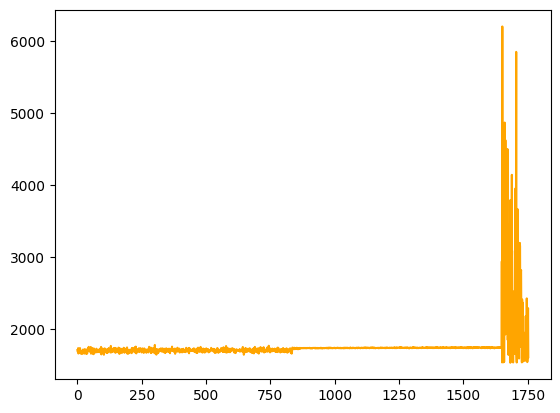

In [220]:
# Moon radius check
distances = rx_ecef_km - moon_ecef_km
distances = np.apply_along_axis(np.linalg.norm, 1, distances)
# print(distances)
# plt.axhline( 1.7374e3, color='b')
plt.plot(distances, color='orange')
# plt.ylim(1.5e3,3.5e3)
plt.show()

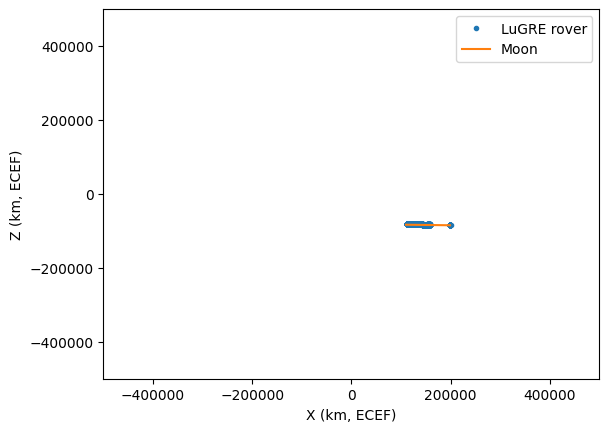

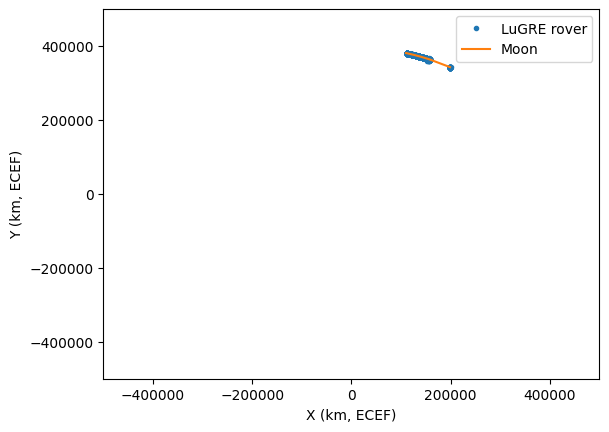

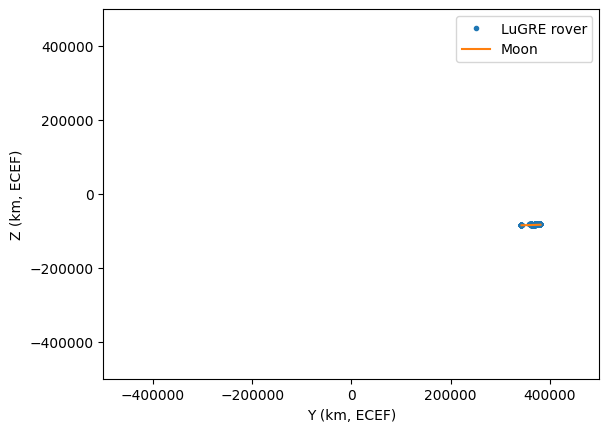

In [221]:
plt.figure()
plt.plot(rx_ecef_km[:,0], rx_ecef_km[:,2], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,0], moon_ecef_km[:,2], '-', label="Moon")
plt.xlabel("X (km, ECEF)")
plt.ylabel("Z (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.legend()
plt.show()

plt.figure()
plt.plot(rx_ecef_km[:,0], rx_ecef_km[:,1], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,0], moon_ecef_km[:,1], '-', label="Moon")
plt.xlabel("X (km, ECEF)")
plt.ylabel("Y (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.legend()
plt.show()

plt.figure()
plt.plot(rx_ecef_km[:,1], rx_ecef_km[:,2], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,1], moon_ecef_km[:,2], '-', label="Moon")
plt.xlabel("Y (km, ECEF)")
plt.ylabel("Z (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.legend()
plt.show()

# More moon

In [224]:
def rover_ecef_to_mcmf_km(rx_ecef_km, t_ast):
    # Convert to meters (lunarsky expects meters)
    coords_m = rx_ecef_km * u.km.to(u.m)

    # Split components
    x = coords_m[:,0] * u.m
    y = coords_m[:,1] * u.m
    z = coords_m[:,2] * u.m


    # Build vectorized ITRS object
    itrs = ITRS(x=x, y=y, z=z, obstime=t_ast)

    # Single transform step (fastest possible)
    mcmf = itrs.transform_to(MCMF(obstime=t_ast))

    # Return km array
    return np.column_stack([
        mcmf.x.to(u.km).value,
        mcmf.y.to(u.km).value,
        mcmf.z.to(u.km).value
    ])

rover_itrs_km = rover_ecef_to_mcmf_km(rx_ecef_km, utc_times)

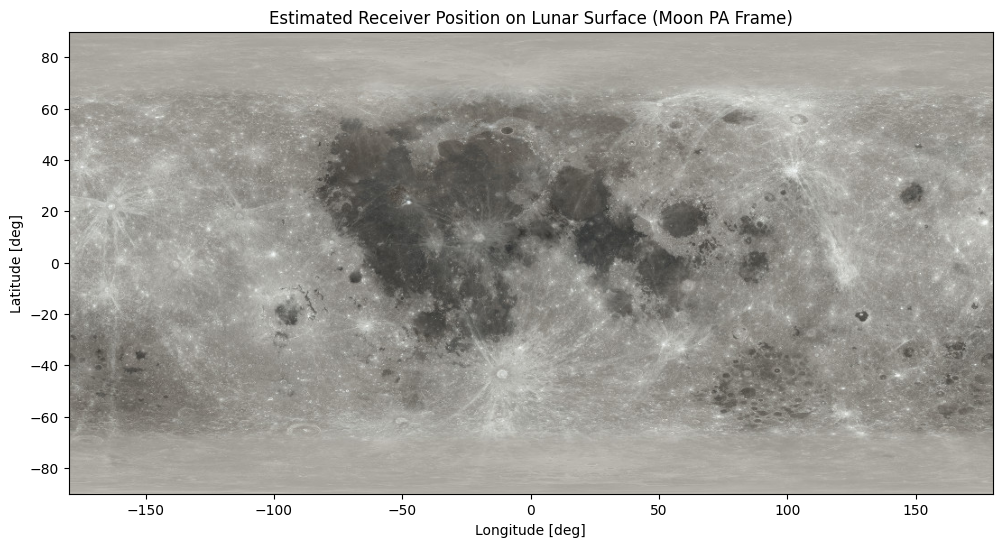

In [ ]:
# plot receiver position in Moon PA frame (assert that all positions are on the Moon surface)
if lugre_df["info"]["phase"][0] == 'S':
    fig, ax = plt.subplots(figsize=(12,6))
    ax.set_xlim(-180,180)
    ax.set_ylim(-90,90)
    ax.set_xlabel("Longitude [deg]")
    ax.set_ylabel("Latitude [deg]")
    ax.set_title("Estimated Receiver Position on Lunar Surface (Moon PA Frame)")

    # load Moon topography image
    img = plt.imread(pnt.LUPNT_DATA_PATH + "/topo/moon_surface.jpeg")
    # flip image vertically and horizontally
    img = img[::-1, ::-1]
    ax.imshow(img, extent=[-180,180,-90,90], alpha=1)

    figobj = [None] * len(rover_itrs_km)
    for i in range(len(rover_itrs_km)):
        # lon_rad, lat_rad, _ = pnt.cartesian_to_geographic(rx_mpa[i, 0], rx_mpa[i, 1], rx_mpa[i, 2], pnt.R_MOON)
        lon, lat, _ = glp.ecef_to_geodetic(rover_itrs_km[i,:])[0]
    #     # print(f"LL: ({lat}, {lon})")
    # #     lon_rad = np.ndarray(lon_rad)
    # #     lat_rad = np.ndarray(lat_rad)
    # #     lon = lon_rad * pnt.DEG
    # #     lat = lat_rad * pnt.DEG
        figobj[i] = ax.plot(lon, lat, 'ro', markersize=2)
    
    # Export figure to pdf
    plt.savefig("NAV_SurfPos.pdf")

In [210]:
# rover_mcmf_km = np.array([make_itrf(x, t) for i,j in zip()])

# # Extract as km for plotting
# rover_mcmf_km = np.column_stack([
#     rover_mcmf.x.to(u.km).value,
#     rover_mcmf.y.to(u.km).value,
#     rover_mcmf.z.to(u.km).value
# ])
print(np.shape(rover_itrs_obj))
# plt.plot(rover_itrs_obj[:,0])
# plt.plot(rover_itrs_obj[:,1])
# plt.plot(rover_itrs_obj[:,2])
# # plt.plot()


(1754, 3)
